In [49]:
import tensorflow as tf
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(threshold=np.inf)


In [3]:
df=pd.read_csv("../DataFrames/NYC_Central_Park_weather_1869-2022.csv")
df['DATE']=pd.to_datetime(df['DATE'])
df["DATE"] = df["DATE"].dt.strftime("%m-%d-%Y")
df['DATE']=pd.to_datetime(df['DATE'])
df.set_index('DATE', inplace=True)



DATE
1869-01-01    24.0
1869-01-02    24.0
1869-01-03    31.0
1869-01-04    35.5
1869-01-05    40.0
Name: Temp, dtype: float64


<Axes: xlabel='DATE'>

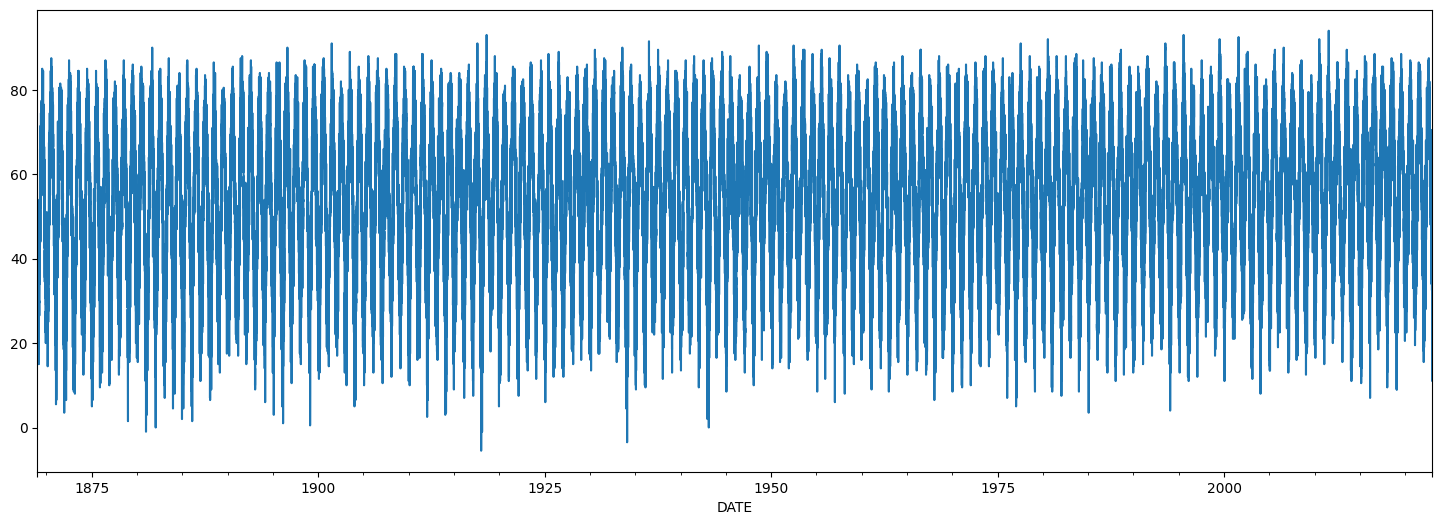

In [4]:
df['Temp']=(df["TMAX"]+df['TMIN'])/2
temp=df['Temp']
#print(temp.isna().sum())
temp = temp.ffill()
#print(temp.isna().sum())
print(temp.head())


temp.plot(figsize=(18, 6))



In [36]:
def seq2seq_data(df, window_size=60, horizon=30):
    df_as_np=df.to_numpy()
    #print(df_as_np)
    X=[]
    y=[]
    for i in range(len(df_as_np)-window_size-horizon):
        row=[[a] for a in df_as_np[i:i+window_size]]
        X.append(row)
        label=[[a] for a in df_as_np[i+window_size:i+window_size+horizon]]
        y.append(label)
    return np.array(X), np.array(y)

HORIZON=30
WINDOW_SIZE=60
X, y =seq2seq_data(temp, WINDOW_SIZE, HORIZON)
X.shape, y.shape


((56155, 60, 1), (56155, 30, 1))

In [37]:
X_train, y_train=X[:46000], y[:46000]
X_val, y_val=X[46000:51150], y[46000:51150]
X_test, y_test=X[51150:], y[51150:]

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((46000, 60, 1),
 (46000, 30, 1),
 (5150, 60, 1),
 (5150, 30, 1),
 (5005, 60, 1),
 (5005, 30, 1))

In [25]:
from tensorflow.keras.models import Model              #to
from tensorflow.keras.layers import *                       #to 
from tensorflow.keras.callbacks import ModelCheckpoint      #to save the model that does best on validations
from tensorflow.keras.losses import MeanSquaredError        # to 
from tensorflow.keras.metrics import RootMeanSquaredError   # sqrt of the errror
from tensorflow.keras.optimizers import Adam

In [38]:
encoder_inputs=Input(shape=(WINDOW_SIZE, 1))
encoder=LSTM(128, return_state=True)
encoder_output, state_h, state_c=encoder(encoder_inputs)
encoder_states=[state_h, state_c]

In [27]:
decoder_inputs=RepeatVector(HORIZON)(encoder_output)
decoder_lstm=LSTM(128, return_sequences=True)
decoder_outputs=decoder_lstm(decoder_inputs, initial_state=encoder_states)

In [30]:
decoder_outputs=TimeDistributed(Dense(1))(decoder_outputs)

In [31]:
model2=Model(encoder_inputs, decoder_outputs)
model2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 128),     │     66,560 │ input_layer[0][0] │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 30, 128)   │          0 │ lstm[0][0]        │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 30, 128)   │    131,584 │ repeat_vector[0]… │
│                     │                   │            │ lstm[0][1],       │
│                     │                   │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 30, 1)     │        129 │ lstm_1[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 198,273 (774.50 KB)

 Trainable params: 198,273 (774.50 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
cp=ModelCheckpoint('model2.keras', save_best_only=True)
model2.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])


In [39]:
model2.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, callbacks=[cp])

Epoch 1/10
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 62s 38ms/step - loss: 1319.5951 - root_mean_squared_error: 36.3262 - val_loss: 824.8452 - val_root_mean_squared_error: 28.7201
Epoch 2/10
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 48s 33ms/step - loss: 543.8546 - root_mean_squared_error: 23.3207 - val_loss: 368.7539 - val_root_mean_squared_error: 19.2030
Epoch 3/10
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 47s 32ms/step - loss: 242.0675 - root_mean_squared_error: 15.5585 - val_loss: 168.4371 - val_root_mean_squared_error: 12.9783
Epoch 4/10
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 47s 33ms/step - loss: 116.3117 - root_mean_squared_error: 10.7848 - val_loss: 92.4064 - val_root_mean_squared_error: 9.6128
Epoch 5/10
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 47s 33ms/step - loss: 74.1536 - root_mean_squared_error: 8.6112 - val_loss: 68.7327 - val_root_mean_squared_error: 8.2905
Epoch 6/10
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 47s 33ms/step - loss: 63.7742 - root_mean_squared_error: 7.9859 - val_loss: 64.5137 - val_root_mean_squared_error: 8.0320
E

In [40]:
from tensorflow.keras.models import load_model
model2=load_model('model2.keras')

In [52]:
last_window=temp.values[-WINDOW_SIZE:]
last_window=np.array([[[a] for a in last_window]])
future_30=model2.predict(last_window)
future_30=future_30.flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


[39.800396 37.19532  35.480434 34.91318  34.675392 34.45702  34.04085
 33.67339  33.410137 33.261753 33.183468 33.015915 32.848587 32.707664
 32.579655 32.455082 32.356766 32.443325 32.801765 32.86221  32.68993
 32.587296 32.767838 32.908913 32.859833 32.757782 32.652035 32.553806
 32.46553  32.387142]


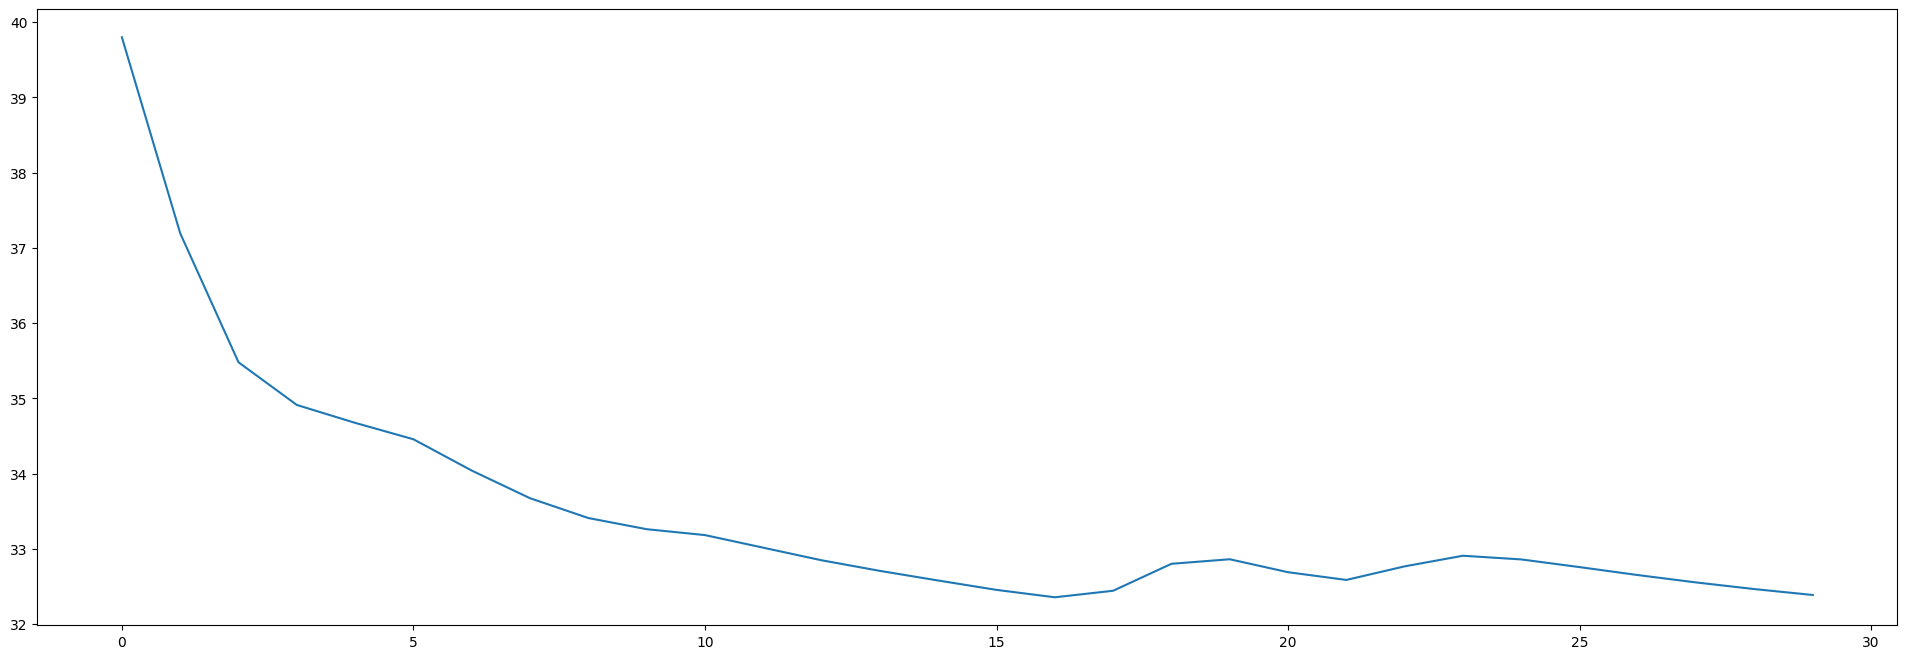

In [54]:
plt.figure(figsize=(24, 8))
plt.plot(range(len(future_30)), future_30)
print(future_30)

In [41]:
train_predicions=model2.predict(X_train).flatten()
train_results=pd.DataFrame(data={'Train Predictions': train_predicions, 'Actuals': y_train})
train_results

1438/1438 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step


ValueError: Per-column arrays must each be 1-dimensional

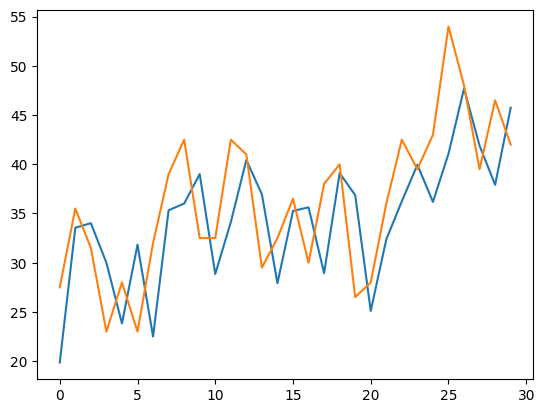

In [ ]:
plt.plot(train_results["Train Predictions"][:30])
plt.plot(train_results["Actuals"][:30])


In [ ]:
val_predicions=model2.predict(X_val).flatten()
val_results=pd.DataFrame(data={'Validation Predictions': val_predicions, 'Actuals': y_val})
val_results


161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


,Validation Predictions,Actuals
0,25.440174,33.5
1,35.186310,38.0
2,34.917088,19.5
3,18.297607,20.0
4,26.444855,27.0
...,...,...
5145,35.357277,33.5
5146,36.570408,41.5
5147,43.403362,46.5
5148,44.878460,43.5


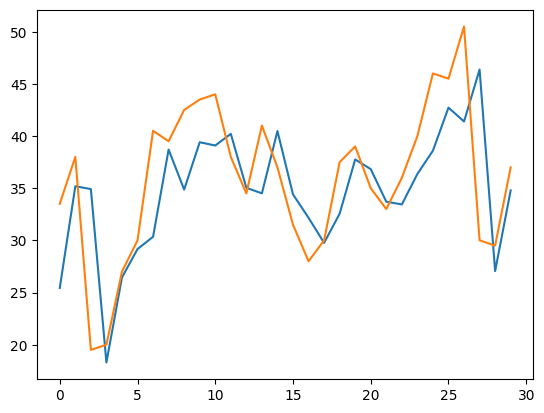

In [ ]:
plt.plot(val_results["Validation Predictions"][:30])
plt.plot(val_results["Actuals"][:30])

In [46]:
test_predictions=np.array(model2.predict(X_test))
print(test_predictions)
test_results=pd.DataFrame(data={'Test Predictions': test_predictions, 'Actuals': y_test})
test_results


157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step
[[[44.178535]
  [43.61342 ]
  [43.570984]
  [43.568863]
  [43.51573 ]
  [43.6939  ]
  [44.11801 ]
  [44.38884 ]
  [44.506603]
  [44.5548  ]
  [44.65487 ]
  [45.120586]
  [45.74952 ]
  [46.185616]
  [46.559322]
  [47.005157]
  [47.528267]
  [47.82958 ]
  [48.01352 ]
  [48.35471 ]
  [48.922073]
  [49.3116  ]
  [49.56301 ]
  [49.77324 ]
  [49.966255]
  [50.172306]
  [50.518356]
  [51.13202 ]
  [51.653008]
  [51.980606]]

 [[47.889965]
  [46.188675]
  [45.649284]
  [45.410217]
  [45.585716]
  [45.861584]
  [45.88032 ]
  [45.76407 ]
  [45.666   ]
  [45.85317 ]
  [46.368603]
  [46.797035]
  [47.45211 ]
  [48.146275]
  [48.53689 ]
  [48.735683]
  [48.875465]
  [49.08178 ]
  [49.56783 ]
  [50.201614]
  [50.63594 ]
  [50.978054]
  [51.295685]
  [51.602764]
  [51.918465]
  [52.33967 ]
  [53.036774]
  [53.717045]
  [54.174805]
  [54.537643]]

 [[45.410603]
  [44.97133 ]
  [45.10782 ]
  [45.254936]
  [45.412514]
  [45.756207]
  [45.99286 ]
  [45.989708]
  

ValueError: Per-column arrays must each be 1-dimensional

In [42]:

plt.plot(range(-1, -1+len(test_results["Test Predictions"][:49])),test_results["Test Predictions"][:49])
plt.plot(test_results["Actuals"][:50])


NameError: name 'test_results' is not defined

In [ ]:
next_100_years=pd.date_range(
    start="01-01-2023",
    periods=36500,
    freq='D'
)
print(next_100_years)

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10',
               ...
               '2122-11-28', '2122-11-29', '2122-11-30', '2122-12-01',
               '2122-12-02', '2122-12-03', '2122-12-04', '2122-12-05',
               '2122-12-06', '2122-12-07'],
              dtype='datetime64[us]', length=36500, freq='D')


In [ ]:
future_predictions=temp.values[-60:].tolist()
for i in range(365):
    currentWindow=np.array([[[a] for a in future_predictions[-WINDOW_SIZE:]]])
    prediction=model2.predict(currentWindow, verbose=0)
    future_predictions.append(prediction[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
11
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
13
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
16
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
17
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
18
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
19
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
22
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
23
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
24
1/1 ━━━━━━━━━━━━━━━━━━━━ 

56245
425
-55820
   values
0    58.0
1    63.0
2    62.0
3    59.5
4    61.5
[58.         63.         62.         59.5        61.5        70.
 70.5        65.5        52.5        46.5        56.5        63.5
 64.5        51.         41.         40.5        44.5        41.5
 39.         35.5        35.         34.         44.         48.5
 47.         50.5        49.5        54.         47.5        40.
 49.         39.         39.5        51.5        41.5        42.
 50.         56.5        48.5        40.5        35.5        36.5
 33.         32.5        35.         37.5        41.         40.
 36.         35.         34.5        33.5        41.         33.
 11.         21.         23.5        32.         40.         45.5
 42.42874527 38.30245972 36.48856735 35.74878311 35.31628036 34.95915604
 34.63936996 34.36444473 34.13527298 33.93901825 33.76288223 33.60926437
 33.48714828 33.39105606 33.29916    33.20182037 33.10787964 33.02310181
 32.94068146 32.85274506 32.754673   32.64920044 

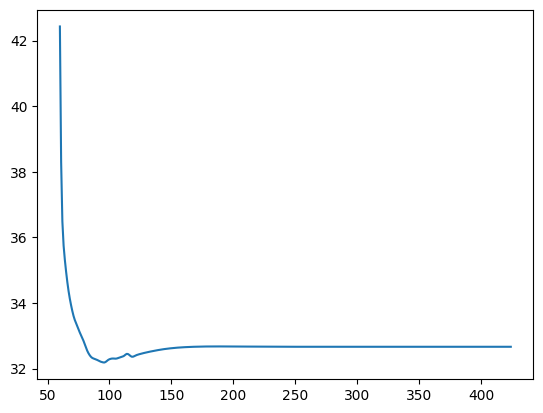

In [ ]:
print(len(temp))
print(len(future_predictions))
print(len(future_predictions)-len(temp))

future_predictions = np.array(future_predictions).reshape(-1)
new_Year=pd.DataFrame({'values': future_predictions})
#print(new_Year.head())
plt.plot(new_Year['values'][60:])
print(future_predictions)